Continuation to Customer Analysis(customer_analysis.sql)

In [4]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os 
import sys

sys.path.append(os.path.abspath("../scripts"))

from db_connection import engine

In [11]:
query = """

SELECT 
    c.customer_unique_id, 
    o.order_id,
    o.order_purchase_timestamp
FROM
    customers c
LEFT JOIN 
    orders o
    ON c.customer_id = o.customer_id 

WHERE 
    o.order_purchase_timestamp < '2018-09-01'
;

"""

df = pd.read_sql(query,engine)
df.head()

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39
2,80bb27c7c16e8f973207a5086ab329e2,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05
3,39382392765b6dc74812866ee5ee92a7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09
4,e97109680b052ee858d93a539597bba7,82566a660a982b15fb86e904c8d32918,2018-06-07 10:06:19


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99421 entries, 0 to 99420
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_unique_id        99421 non-null  str           
 1   order_id                  99421 non-null  str           
 2   order_purchase_timestamp  99421 non-null  datetime64[us]
dtypes: datetime64[us](1), str(2)
memory usage: 2.3 MB


In [15]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.columns = ['customer_id','order_id','purchase_date']

In [21]:
df.head()

,customer_id,order_id,purchase_date
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39
2,80bb27c7c16e8f973207a5086ab329e2,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05
3,39382392765b6dc74812866ee5ee92a7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09
4,e97109680b052ee858d93a539597bba7,82566a660a982b15fb86e904c8d32918,2018-06-07 10:06:19


Cohort MOnth 

In [44]:
df['cohort_month'] = (df.groupby('customer_id')['purchase_date'].transform('min').dt.to_period('M'))

# First purchase Month as cohort

In [40]:
#purchase month
df['purchase_month'] = (df['purchase_date'].dt.to_period('M')) 

# months since first purchase 

df['cohort_index'] = (
    (df['purchase_month'].dt.year 
     - df['cohort_month'].dt.year)*12

            +

    (df['purchase_month'].dt.month
     - df['cohort_month'].dt.month)

     + 1
)
df['cohort_index'].value_counts()


cohort_index
1     97412
2       467
3       299
4       213
5       189
6       154
7       137
8       107
9        94
11       79
10       68
12       60
13       41
14       26
15       24
16       22
18       13
17       11
20        3
21        2
Name: count, dtype: int64

In [46]:
cohort_data = (

    df.groupby(
        ['cohort_month','cohort_index']
    )['customer_id']

    .nunique()

    .reset_index()
)

cohort_data

,cohort_month,cohort_index,customer_id
0,2016-09,1,4
1,2016-10,1,321
2,2016-10,7,1
3,2016-10,10,1
4,2016-10,12,1
...,...,...,...
214,2018-06,2,25
215,2018-06,3,17
216,2018-07,1,6071
217,2018-07,2,44


Severe churn 

In [53]:
retention_table = cohort_data.pivot(

    index='cohort_month',
    columns='cohort_index',
    values='customer_id'

)
retention_table.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN


In [52]:
cohort_size = retention_table.iloc[:,0]

retention_matrix = retention_table.divide(
    cohort_size,
    axis=0
)

retention_matrix = retention_matrix.round(3) * 100

retention_matrix.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN,0.3,NaN,0.3,NaN,0.3,NaN,0.3,NaN,0.3,0.6,0.6
2016-12,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.4,0.3,0.1,0.4,0.1,0.5,0.1,0.1,NaN,0.4,0.1,0.8,0.4,0.1,0.1,0.3,0.4,0.1,NaN
2017-02,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2,0.2,0.2,0.1,0.3,0.2,0.2,0.1,0.1,0.1,0.2,NaN,NaN


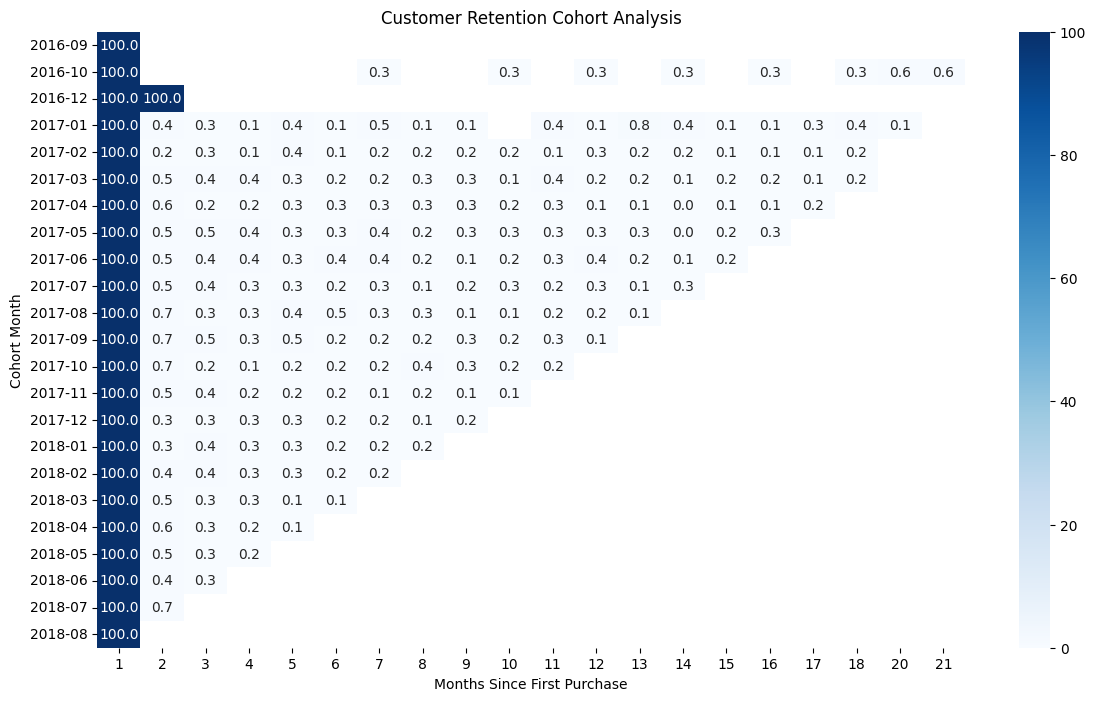

In [58]:
## heatmap 

plt.figure(figsize=(14,8))

sns.heatmap(

    retention_matrix,

    annot=True,
    fmt='.1f',

    cmap='Blues'

)

plt.title('Customer Retention Cohort Analysis')

plt.xlabel('Months Since First Purchase')

plt.ylabel('Cohort Month')

plt.show()

- Olist showed extremely weak customer retention, with most cohorts collapsing after the first purchase month.

- Nearly all customers behaved as one-time buyers, confirming that growth was driven primarily by continuous customer acquisition rather than long-term loyalty.

- The business should prioritize retention systems such as loyalty programs, CRM personalization, seller quality improvements, and post-purchase engagement to improve customer lifetime value and reduce acquisition dependency.

next --> Delivery/Operations Anlalysis